In [4]:
import subprocess
subprocess.run(["py", "-m", "pip", "uninstall", "matplotlib", "-y"])
subprocess.run(["py", "-m", "pip", "install", "matplotlib", "--upgrade"])
print("Done")

Done


In [6]:
# Load the dataset
df = pd.read_csv('creditcard.csv')

# Basic exploration
print("Shape:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (284807, 31)

Column names: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

First 5 rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [8]:
# Check class distribution
fraud_counts = df['Class'].value_counts()
fraud_pct = df['Class'].value_counts(normalize=True) * 100

print("Transaction counts:")
print(fraud_counts)
print("\nPercentage breakdown:")
print(fraud_pct.round(2))

Transaction counts:
Class
0    284315
1       492
Name: count, dtype: int64

Percentage breakdown:
Class
0    99.83
1     0.17
Name: proportion, dtype: float64


C:\Users\bdben\AppData\Local\Temp\ipykernel_25828\4114928760.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, palette=['#2E75B6', '#E8452C'])


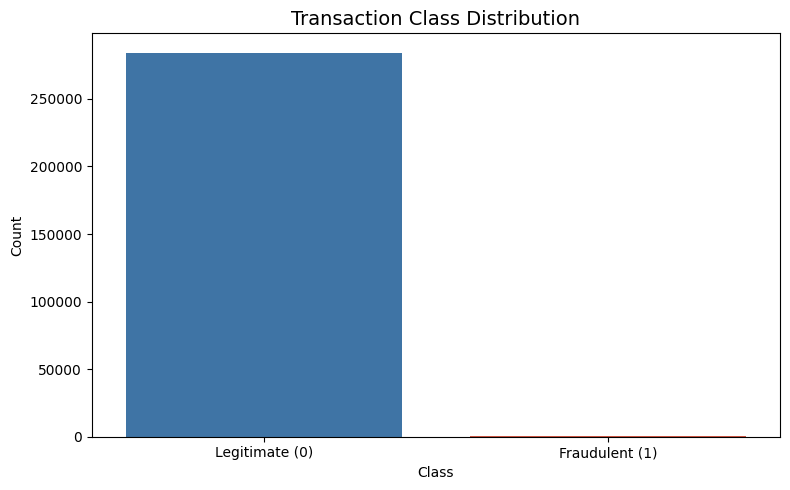

Chart saved


In [10]:
# Visualise class imbalance
plt.figure(figsize=(8, 5))
sns.countplot(x='Class', data=df, palette=['#2E75B6', '#E8452C'])
plt.title('Transaction Class Distribution', fontsize=14)
plt.xticks([0, 1], ['Legitimate (0)', 'Fraudulent (1)'])
plt.ylabel('Count')
plt.xlabel('Class')
plt.tight_layout()
plt.savefig('class_distribution.png')
plt.show()
print("Chart saved")

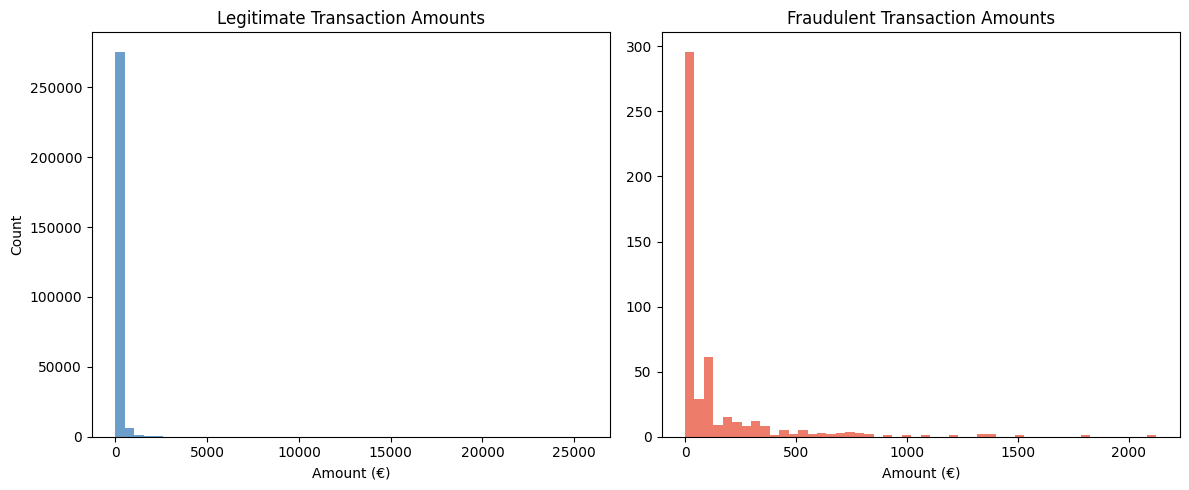

Charts saved


In [12]:
# Compare transaction amounts
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Legitimate transactions
axes[0].hist(df[df['Class']==0]['Amount'], 
             bins=50, color='#2E75B6', alpha=0.7)
axes[0].set_title('Legitimate Transaction Amounts')
axes[0].set_xlabel('Amount (€)')
axes[0].set_ylabel('Count')

# Fraudulent transactions
axes[1].hist(df[df['Class']==1]['Amount'], 
             bins=50, color='#E8452C', alpha=0.7)
axes[1].set_title('Fraudulent Transaction Amounts')
axes[1].set_xlabel('Amount (€)')

plt.tight_layout()
plt.savefig('amount_distribution.png')
plt.show()
print("Charts saved")

In [14]:
# Statistical comparison of amounts
legit = df[df['Class']==0]['Amount']
fraud = df[df['Class']==1]['Amount']

print("Legitimate Transactions:")
print(f"  Average amount: €{legit.mean():.2f}")
print(f"  Median amount:  €{legit.median():.2f}")
print(f"  Max amount:     €{legit.max():.2f}")

print("\nFraudulent Transactions:")
print(f"  Average amount: €{fraud.mean():.2f}")
print(f"  Median amount:  €{fraud.median():.2f}")
print(f"  Max amount:     €{fraud.max():.2f}")

Legitimate Transactions:
  Average amount: €88.29
  Median amount:  €22.00
  Max amount:     €25691.16

Fraudulent Transactions:
  Average amount: €122.21
  Median amount:  €9.25
  Max amount:     €2125.87


In [16]:
# Separate features and target
X = df.drop('Class', axis=1)
y = df['Class']

# Scale the Amount and Time columns
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X['Amount'] = scaler.fit_transform(X[['Amount']])
X['Time'] = scaler.fit_transform(X[['Time']])

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

print(f"Training set size: {X_train.shape[0]:,}")
print(f"Test set size:     {X_test.shape[0]:,}")
print(f"\nFraud cases in training: {y_train.sum():,}")
print(f"Fraud cases in test:     {y_test.sum():,}")

Training set size: 227,845
Test set size:     56,962

Fraud cases in training: 394
Fraud cases in test:     98


In [18]:
# Train logistic regression model
# class_weight balanced handles the imbalance automatically
model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

model.fit(X_train, y_train)
print("Model trained successfully")

Model trained successfully


In [20]:
# Make predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Print classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, 
      target_names=['Legitimate', 'Fraud']))

# ROC AUC Score
roc_score = roc_auc_score(y_test, y_prob)
print(f"ROC AUC Score: {roc_score:.4f}")

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      0.98      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962

ROC AUC Score: 0.9722


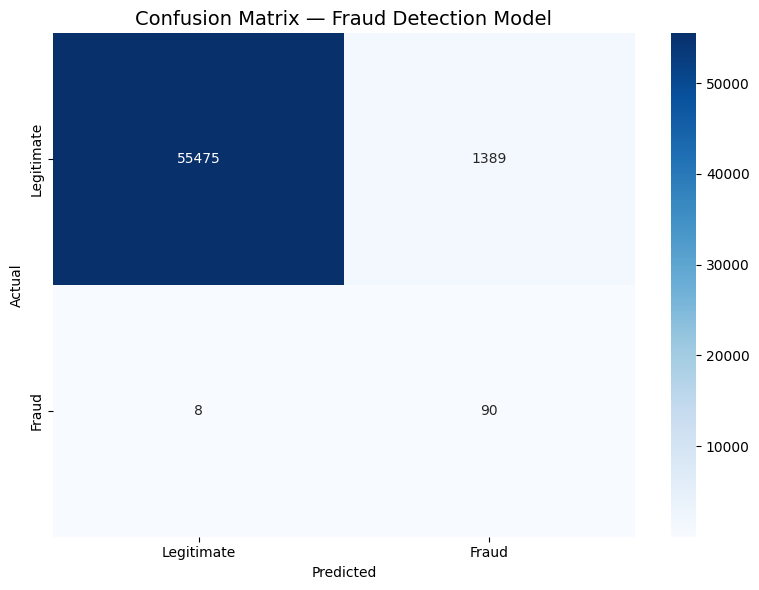

True Negatives  (Correct legitimate): 55,475
False Positives (Legitimate flagged as fraud): 1,389
False Negatives (Fraud missed): 8
True Positives  (Fraud correctly caught): 90


In [22]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'])
plt.title('Confusion Matrix — Fraud Detection Model', fontsize=14)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

# Break down the numbers
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (Correct legitimate): {tn:,}")
print(f"False Positives (Legitimate flagged as fraud): {fp:,}")
print(f"False Negatives (Fraud missed): {fn:,}")
print(f"True Positives  (Fraud correctly caught): {tp:,}")

In [24]:
# Calculate business impact
avg_fraud_amount = 122.21  # from our earlier analysis

print("=== BUSINESS IMPACT ANALYSIS ===")
print(f"\nFraud cases correctly caught: {tp}")
print(f"Estimated fraud prevented: €{tp * avg_fraud_amount:,.2f}")

print(f"\nFraud cases missed: {fn}")
print(f"Estimated fraud missed: €{fn * avg_fraud_amount:,.2f}")

print(f"\nLegitimate transactions wrongly blocked: {fp:,}")
print(f"Estimated lost revenue from false blocks: €{fp * 88.29:,.2f}")

print(f"\nNet benefit of model: €{(tp * avg_fraud_amount) - (fp * 88.29):,.2f}")

=== BUSINESS IMPACT ANALYSIS ===

Fraud cases correctly caught: 90
Estimated fraud prevented: €10,998.90

Fraud cases missed: 8
Estimated fraud missed: €977.68

Legitimate transactions wrongly blocked: 1,389
Estimated lost revenue from false blocks: €122,634.81

Net benefit of model: €-111,635.91


In [26]:
# Try different thresholds and find the best one
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

print(f"{'Threshold':<12} {'Fraud Caught':<14} {'False Blocks':<14} {'Net Benefit':>12}")
print("-" * 55)

for threshold in thresholds:
    y_pred_t = (y_prob >= threshold).astype(int)
    cm_t = confusion_matrix(y_test, y_pred_t)
    tn_t, fp_t, fn_t, tp_t = cm_t.ravel()
    
    fraud_saved = tp_t * 122.21
    revenue_lost = fp_t * 88.29
    net = fraud_saved - revenue_lost
    
    print(f"{threshold:<12} {tp_t:<14} {fp_t:<14} €{net:>10,.2f}")

Threshold    Fraud Caught   False Blocks    Net Benefit
-------------------------------------------------------
0.1          93             11360          €-991,608.87
0.2          92             5532           €-477,176.96
0.3          90             3205           €-271,970.55
0.4          90             2046           €-169,642.44
0.5          90             1389           €-111,635.91
0.6          89             938            €-71,939.33
0.7          89             643            €-45,893.78
0.8          87             459            €-29,892.84
0.9          87             266            €-12,852.87


In [27]:
# Export threshold analysis for Power BI
threshold_data = []

for threshold in thresholds:
    y_pred_t = (y_prob >= threshold).astype(int)
    cm_t = confusion_matrix(y_test, y_pred_t)
    tn_t, fp_t, fn_t, tp_t = cm_t.ravel()
    
    threshold_data.append({
        'threshold': threshold,
        'fraud_caught': tp_t,
        'fraud_missed': fn_t,
        'false_blocks': fp_t,
        'true_negatives': tn_t,
        'net_benefit': round((tp_t * 122.21) - (fp_t * 88.29), 2)
    })

threshold_df = pd.DataFrame(threshold_data)
threshold_df.to_csv('threshold_analysis.csv', index=False)
print("Saved threshold_analysis.csv")

# Export fraud summary stats
summary = {
    'total_transactions': [len(df)],
    'total_fraud': [df['Class'].sum()],
    'fraud_pct': [round(df['Class'].mean() * 100, 2)],
    'avg_legitimate_amount': [round(legit.mean(), 2)],
    'avg_fraud_amount': [round(fraud.mean(), 2)],
    'model_auc': [0.9722],
    'best_threshold': [0.9],
    'fraud_caught_at_best': [87],
    'false_blocks_at_best': [266]
}

summary_df = pd.DataFrame(summary)
summary_df.to_csv('fraud_summary.csv', index=False)
print("Saved fraud_summary.csv")

Saved threshold_analysis.csv
Saved fraud_summary.csv
